In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import statsmodels.formula.api as smf
import statsmodels.api as sm
from scipy import stats
df_raw = pd.read_csv('fuel_merged (2).csv')
df_raw

,Year,State Code,Fuel Source,Nameplate Capacity (Megawatts),renew_share,ipp_share,fossil_share,res_price,com_price,ind_price
0,2014,AK,Coal,113.5,19.4,0.7,78.0,19.14,17.09,15.66
1,2014,AK,Hydroelectric,440.4,19.4,0.7,78.0,19.14,17.09,15.66
2,2014,AK,Natural Gas,1233.2,19.4,0.7,78.0,19.14,17.09,15.66
3,2014,AK,Other,70.0,19.4,0.7,78.0,19.14,17.09,15.66
4,2014,AK,Other Biomass,11.5,19.4,0.7,78.0,19.14,17.09,15.66
...,...,...,...,...,...,...,...,...,...,...
4782,2023,WY,Other,13.3,32.6,14.5,67.2,11.46,8.94,7.06
4783,2023,WY,Other Gases,3.7,32.6,14.5,67.2,11.46,8.94,7.06
4784,2023,WY,Petroleum,5.8,32.6,14.5,67.2,11.46,8.94,7.06
4785,2023,WY,Solar Thermal and Photovoltaic,92.0,32.6,14.5,67.2,11.46,8.94,7.06


In [24]:
df_raw.columns

Index(['Year', 'State Code', 'Fuel Source', 'Nameplate Capacity (Megawatts)',
       'renew_share', 'ipp_share', 'fossil_share', 'res_price', 'com_price',
       'ind_price'],
      dtype='object')

In [25]:
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({"Count": missing, "Percent (%)": missing_pct})

In [ ]:
dupes = df_raw.duplicated().sum()

np.int64(0)

In [28]:
df = (df_raw
      .drop_duplicates(subset=["Year", "State Code"])
      .loc[:, ["Year", "State Code", "renew_share", "ipp_share",
               "fossil_share", "res_price", "com_price", "ind_price"]]
      .rename(columns={"State Code": "state"})  # shorter name for formulas
      .reset_index(drop=True))

In [ ]:
df

,Year,state,renew_share,ipp_share,fossil_share,res_price,com_price,ind_price
0,2014,AK,19.4,0.7,78.0,19.14,17.09,15.66
1,2014,AL,11.6,23.3,73.1,11.48,10.79,6.15
2,2014,AR,10.4,19.4,78.2,9.51,8.05,6.02
3,2014,AZ,13.9,25.6,72.3,11.90,10.13,6.46
4,2014,CA,32.8,53.6,59.0,16.25,15.62,12.34
...,...,...,...,...,...,...,...,...
515,2023,VT,79.2,46.5,18.5,20.82,18.00,11.27
516,2023,WA,79.9,12.1,15.2,10.98,9.92,6.35
517,2023,WI,17.8,9.3,75.5,16.88,12.76,8.68
518,2023,WV,7.8,25.5,91.9,14.05,11.03,7.24


In [30]:
df_clean = df.dropna().copy()
df_clean

,Year,state,renew_share,ipp_share,fossil_share,res_price,com_price,ind_price
0,2014,AK,19.4,0.7,78.0,19.14,17.09,15.66
1,2014,AL,11.6,23.3,73.1,11.48,10.79,6.15
2,2014,AR,10.4,19.4,78.2,9.51,8.05,6.02
3,2014,AZ,13.9,25.6,72.3,11.90,10.13,6.46
4,2014,CA,32.8,53.6,59.0,16.25,15.62,12.34
...,...,...,...,...,...,...,...,...
515,2023,VT,79.2,46.5,18.5,20.82,18.00,11.27
516,2023,WA,79.9,12.1,15.2,10.98,9.92,6.35
517,2023,WI,17.8,9.3,75.5,16.88,12.76,8.68
518,2023,WV,7.8,25.5,91.9,14.05,11.03,7.24


In [31]:
df_clean[["renew_share", "fossil_share", "ipp_share",
                    "res_price", "com_price", "ind_price"]].describe().round(2)

,renew_share,fossil_share,ipp_share,res_price,com_price,ind_price
count,515.00,515.00,515.00,515.00,515.00,515.00
mean,23.79,67.30,36.87,14.08,11.45,8.30
std,21.31,19.18,30.16,4.70,4.04,3.94
min,1.20,15.20,0.40,8.67,7.38,4.32
25%,7.80,57.80,12.80,11.20,9.11,6.17
50%,16.80,70.20,25.20,12.54,10.28,7.06
75%,32.75,80.30,60.80,15.24,12.10,8.24
max,83.20,98.80,99.40,43.03,40.18,36.71


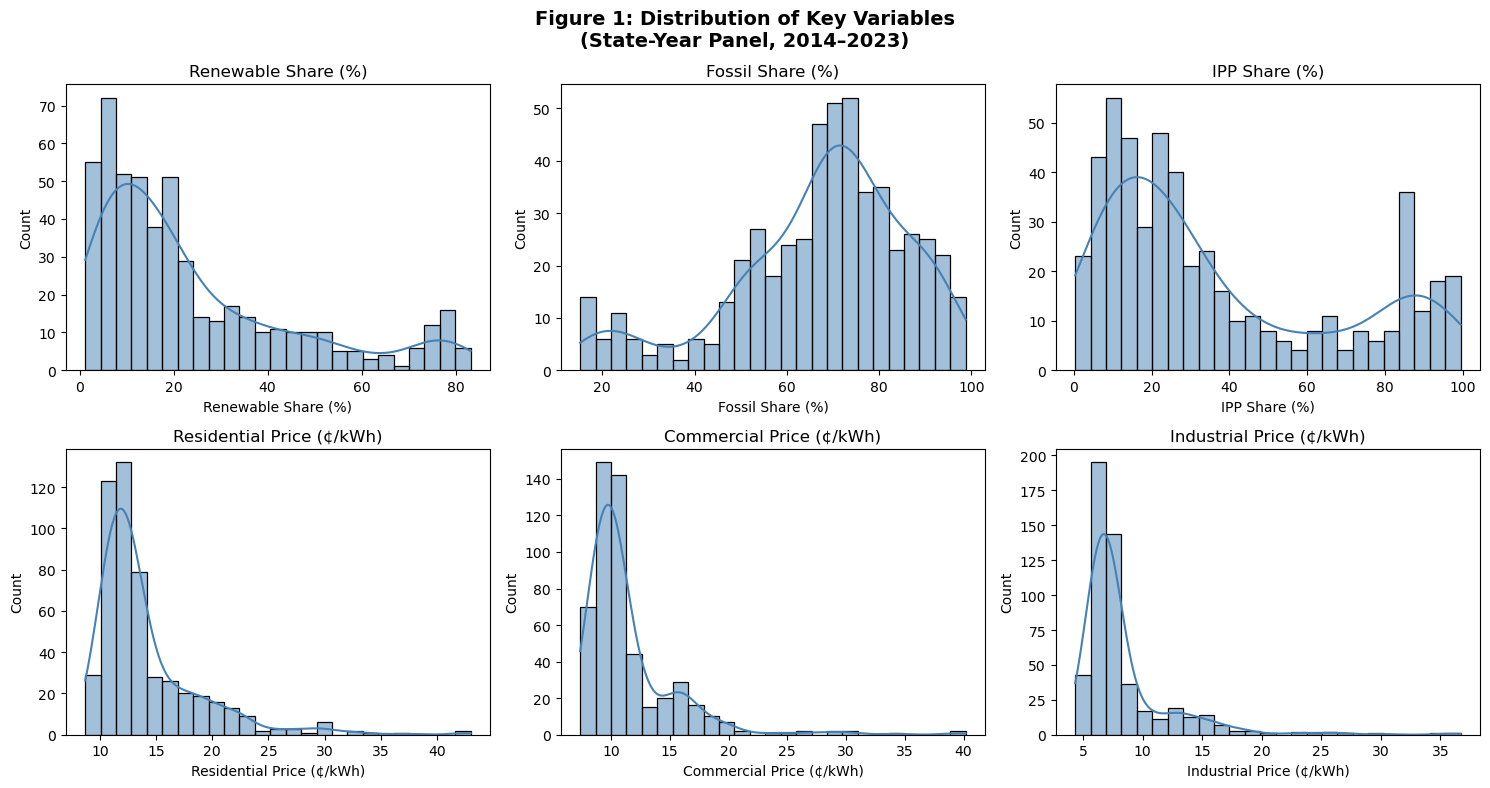

In [32]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("Figure 1: Distribution of Key Variables\n(State-Year Panel, 2014–2023)",
             fontsize=14, fontweight="bold")
 
vars_to_plot = [
    ("renew_share", "Renewable Share (%)"),
    ("fossil_share", "Fossil Share (%)"),
    ("ipp_share", "IPP Share (%)"),
    ("res_price", "Residential Price (¢/kWh)"),
    ("com_price", "Commercial Price (¢/kWh)"),
    ("ind_price", "Industrial Price (¢/kWh)"),
]
 
for ax, (col, label) in zip(axes.flat, vars_to_plot):
    sns.histplot(df_clean[col], kde=True, ax=ax, color="steelblue", bins=25)
    ax.set_xlabel(label)
    ax.set_ylabel("Count")
    ax.set_title(label)
 
plt.tight_layout()
plt.savefig("fig1_distributions.png", bbox_inches="tight")
plt.show()

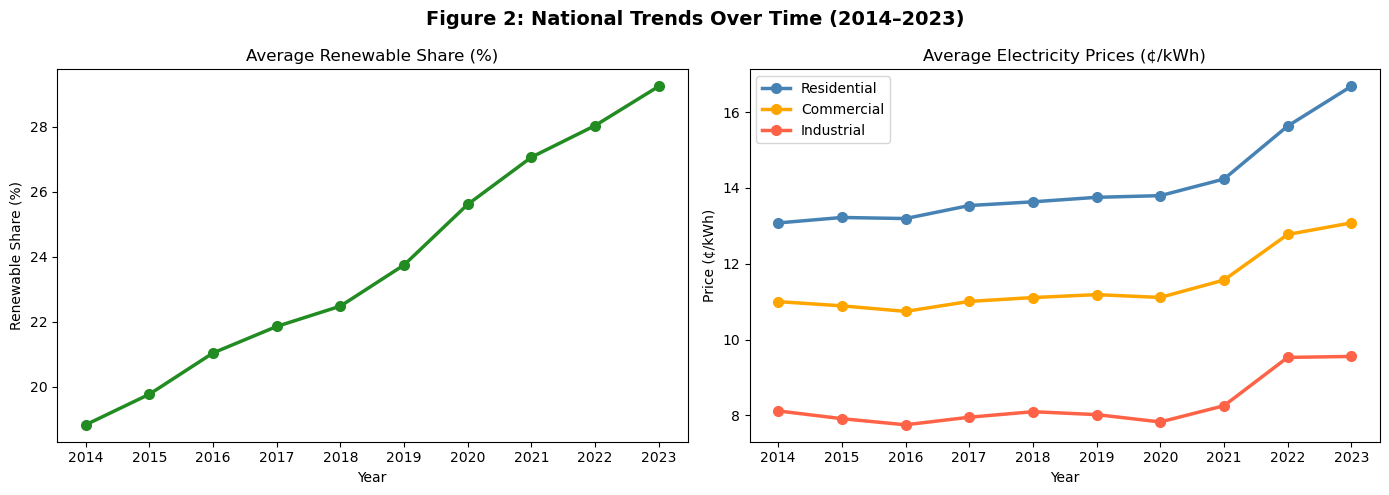

In [33]:
yearly = df_clean.groupby("Year")[
    ["renew_share", "res_price", "com_price", "ind_price"]].mean().reset_index()
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Figure 2: National Trends Over Time (2014–2023)", fontsize=14, fontweight="bold")
 
# Plot 1: Renewable share over time
axes[0].plot(yearly["Year"], yearly["renew_share"], marker="o",
             color="forestgreen", linewidth=2.5, markersize=7)
axes[0].set_title("Average Renewable Share (%)")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Renewable Share (%)")
axes[0].xaxis.set_major_locator(mticker.MultipleLocator(1))
 
# Plot 2: All three prices over time
for col, label, color in [("res_price", "Residential", "steelblue"),
                           ("com_price", "Commercial", "orange"),
                           ("ind_price", "Industrial", "tomato")]:
    axes[1].plot(yearly["Year"], yearly[col], marker="o",
                 label=label, linewidth=2.5, markersize=7, color=color)
axes[1].set_title("Average Electricity Prices (¢/kWh)")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Price (¢/kWh)")
axes[1].legend()
axes[1].xaxis.set_major_locator(mticker.MultipleLocator(1))
 
plt.tight_layout()
plt.savefig("fig2_time_trends.png", bbox_inches="tight")
plt.show()

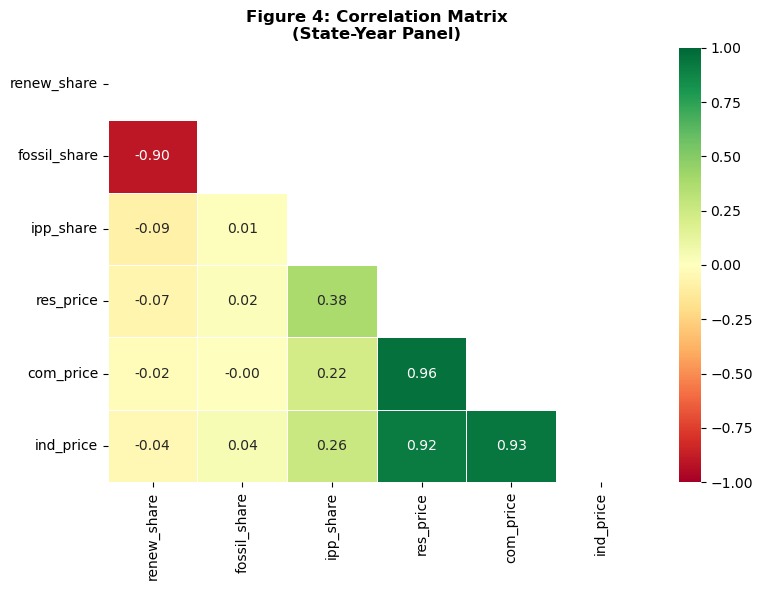

In [34]:
fig, ax = plt.subplots(figsize=(8, 6))
corr_cols = ["renew_share", "fossil_share", "ipp_share",
             "res_price", "com_price", "ind_price"]
corr_matrix = df_clean[corr_cols].corr().round(2)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, mask=mask, ax=ax, linewidths=0.5, vmin=-1, vmax=1)
ax.set_title("Figure 4: Correlation Matrix\n(State-Year Panel)", fontweight="bold")
plt.tight_layout()
plt.savefig("fig4_correlation_heatmap.png", bbox_inches="tight")
plt.show()

In [35]:
model1 = smf.ols("res_price ~ renew_share", data=df_clean).fit()
model1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              res_price   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     2.200
Date:                Sun, 03 May 2026   Prob (F-statistic):              0.139
Time:                        11:15:58   Log-Likelihood:                -1526.2
No. Observations:                 515   AIC:                             3056.
Df Residuals:                     513   BIC:                             3065.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      14.4254      0.310     46.493      0.000      13.816      15.035
renew_share    -0.0144      0.010     -1.483      0.139      -0.034       0.005
==============================================================================
Omnibus:                      286.022   Durbin-Watson:                   2.049
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1855.901
Skew:                           2.433   Prob(JB):                         0.00
Kurtosis:                      10.926   Cond. No.                         47.9
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [36]:
model2 = smf.ols("res_price ~ renew_share + fossil_share + ipp_share + Year",
                 data=df_clean).fit()
model2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              res_price   R-squared:                       0.183
Model:                            OLS   Adj. R-squared:                  0.177
Method:                 Least Squares   F-statistic:                     28.59
Date:                Sun, 03 May 2026   Prob (F-statistic):           1.88e-21
Time:                        11:16:39   Log-Likelihood:                -1475.2
No. Observations:                 515   AIC:                             2960.
Df Residuals:                     510   BIC:                             2982.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept     -619.2153    134.425     -4.606      0.000    -883.309    -355.121
renew_share     -0.0262      0.021     -1.263      0.207      -0.067       0.015
fossil_share    -0.0152      0.023     -0.660      0.510      -0.060       0.030
ipp_share        0.0560      0.006      8.805      0.000       0.043       0.068
Year             0.3135      0.067      4.710      0.000       0.183       0.444
==============================================================================
Omnibus:                      362.239   Durbin-Watson:                   2.147
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             4321.051
Skew:                           3.022   Prob(JB):                         0.00
Kurtosis:                      15.839   Cond. No.                     1.45e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.45e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [37]:
model3 = smf.ols("res_price ~ renew_share + fossil_share + ipp_share + Year + C(state)",
                 data=df_clean).fit(cov_type="HC3")
model3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              res_price   R-squared:                       0.933
Model:                            OLS   Adj. R-squared:                  0.925
Method:                 Least Squares   F-statistic:                     112.5
Date:                Sun, 03 May 2026   Prob (F-statistic):          4.90e-232
Time:                        11:17:45   Log-Likelihood:                -831.82
No. Observations:                 515   AIC:                             1776.
Df Residuals:                     459   BIC:                             2013.
Df Model:                          55                                         
Covariance Type:                  HC3                                         
==================================================================================
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept       -695.6069     75.856     -9.170      0.000    -844.282    -546.932
C(state)[T.AL]   -15.1106      2.255     -6.700      0.000     -19.531     -10.690
C(state)[T.AR]   -15.0081      1.378    -10.889      0.000     -17.710     -12.307
C(state)[T.AZ]   -14.1751      1.905     -7.441      0.000     -17.909     -10.441
C(state)[T.CA]    -4.8761      1.779     -2.741      0.006      -8.363      -1.389
C(state)[T.CO]   -10.3043      0.895    -11.514      0.000     -12.058      -8.550
C(state)[T.CT]   -10.4822      4.590     -2.284      0.022     -19.479      -1.485
C(state)[T.DC]    -7.4359      0.829     -8.965      0.000      -9.062      -5.810
C(state)[T.DE]   -12.3520      3.206     -3.853      0.000     -18.636      -6.068
C(state)[T.FL]   -11.9575      0.941    -12.706      0.000     -13.802     -10.113
C(state)[T.GA]   -14.9224      1.990     -7.498      0.000     -18.823     -11.022
C(state)[T.HI]    10.8079      1.515      7.135      0.000       7.839      13.777
C(state)[T.IA]    -8.8325      0.620    -14.256      0.000     -10.047      -7.618
C(state)[T.ID]    -9.5810      1.224     -7.830      0.000     -11.979      -7.183
C(state)[T.IL]   -19.8191      4.516     -4.389      0.000     -28.670     -10.968
C(state)[T.IN]    -9.5179      0.731    -13.012      0.000     -10.952      -8.084
C(state)[T.KS]   -10.9376      1.081    -10.119      0.000     -13.056      -8.819
C(state)[T.KY]   -10.9189      0.659    -16.574      0.000     -12.210      -9.628
C(state)[T.LA]   -15.0296      1.303    -11.531      0.000     -17.584     -12.475
C(state)[T.MA]    -7.7555      3.686     -2.104      0.035     -14.980      -0.531
C(state)[T.MD]   -15.6678      3.639     -4.306      0.000     -22.800      -8.536
C(state)[T.ME]    -5.4881      2.068     -2.654      0.008      -9.541      -1.435
C(state)[T.MI]   -11.9170      2.367     -5.035      0.000     -16.556      -7.278
C(state)[T.MN]   -11.7383      1.330     -8.825      0.000     -14.345      -9.131
C(state)[T.MO]   -12.9982      0.986    -13.186      0.000     -14.930     -11.066
C(state)[T.MS]   -13.4555      1.154    -11.656      0.000     -15.718     -11.193
C(state)[T.MT]   -10.5020      0.906    -11.595      0.000     -12.277      -8.727
C(state)[T.NC]   -15.2600      1.880     -8.116      0.000     -18.945     -11.575
C(state)[T.ND]   -10.5138      0.550    -19.099      0.000     -11.593      -9.435
C(state)[T.NE]   -13.8441      1.180    -11.728      0.000     -16.158     -11.530
C(state)[T.NH]   -12.3593      4.162     -2.970      0.003     -20.516      -4.203
C(state)[T.NJ]   -16.5210      4.378     -3.773      0.000     -25.102      -7.940
C(state)[T.NM]    -9.1686      0.834    -10.991      0.000     -10.804      -7.534
C(state)[T.NV]    -9.1606      0.720    -12.729      0.000     -10.571      -7.750
C(state)[T.N

In [38]:
models_fe = {}
price_labels = {"res_price": "Residential", "com_price": "Commercial", "ind_price": "Industrial"}
 
for price_col, label in price_labels.items():
    m = smf.ols(f"{price_col} ~ renew_share + fossil_share + ipp_share + Year + C(state)",
                data=df_clean).fit(cov_type="HC3")
    models_fe[price_col] = m
 
# Summary comparison table
print("\n📊 Comparison Table: renew_share coefficient across all three models")
comparison = pd.DataFrame({
    label: {
        "Coefficient":    round(models_fe[col].params["renew_share"], 4),
        "Std. Error":     round(models_fe[col].bse["renew_share"], 4),
        "p-value":        round(models_fe[col].pvalues["renew_share"], 4),
        "Significant?":   "✅" if models_fe[col].pvalues["renew_share"] < 0.05 else "❌",
        "95% CI Lower":   round(models_fe[col].conf_int().loc["renew_share", 0], 4),
        "95% CI Upper":   round(models_fe[col].conf_int().loc["renew_share", 1], 4),
        "Adj. R²":        round(models_fe[col].rsquared_adj, 4),
    }
    for col, label in price_labels.items()
}).T
 
print(comparison.to_string())


📊 Comparison Table: renew_share coefficient across all three models
            Coefficient Std. Error p-value Significant? 95% CI Lower 95% CI Upper Adj. R²
Residential      -0.366     0.1309  0.0052            ✅      -0.6225      -0.1095  0.9248
Commercial      -0.3294     0.1157  0.0044            ✅      -0.5561      -0.1026  0.9409
Industrial      -0.3105      0.115   0.007            ✅       -0.536       -0.085  0.9418
